In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


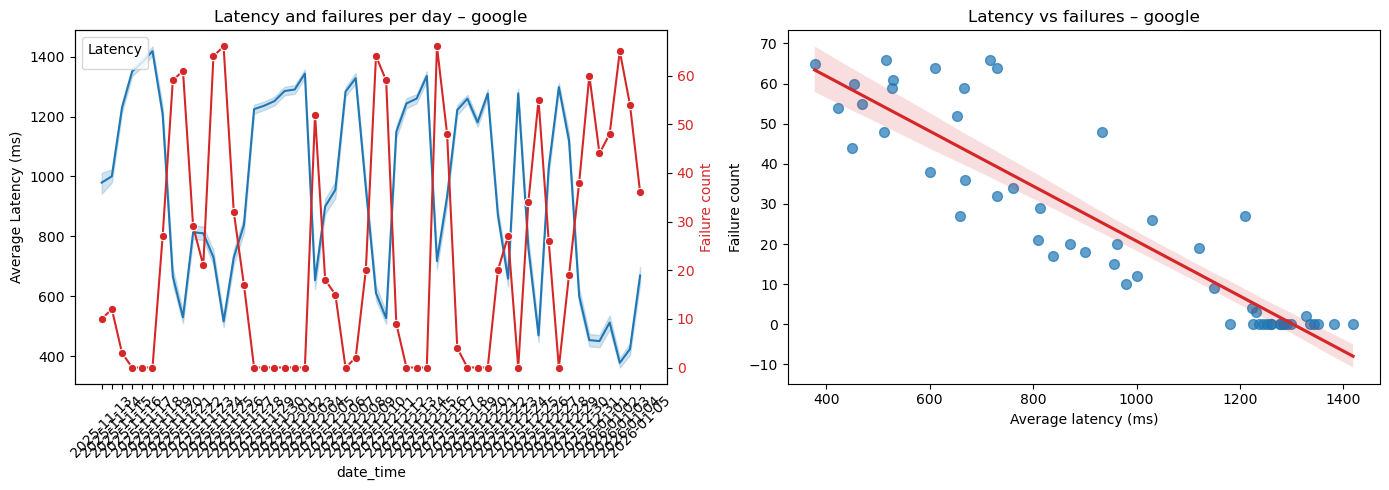

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


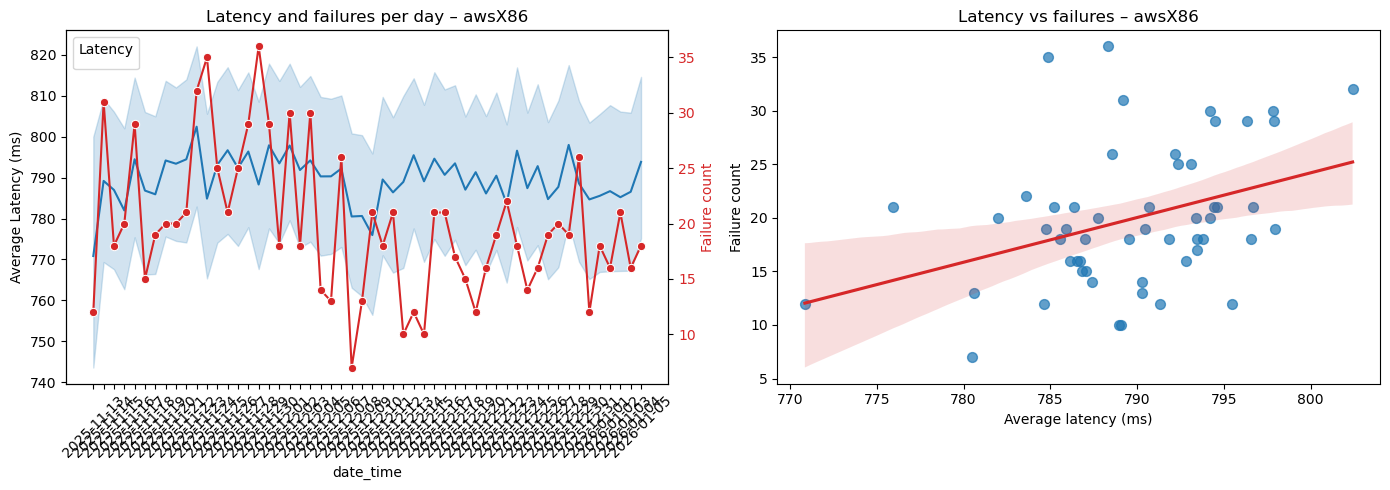

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


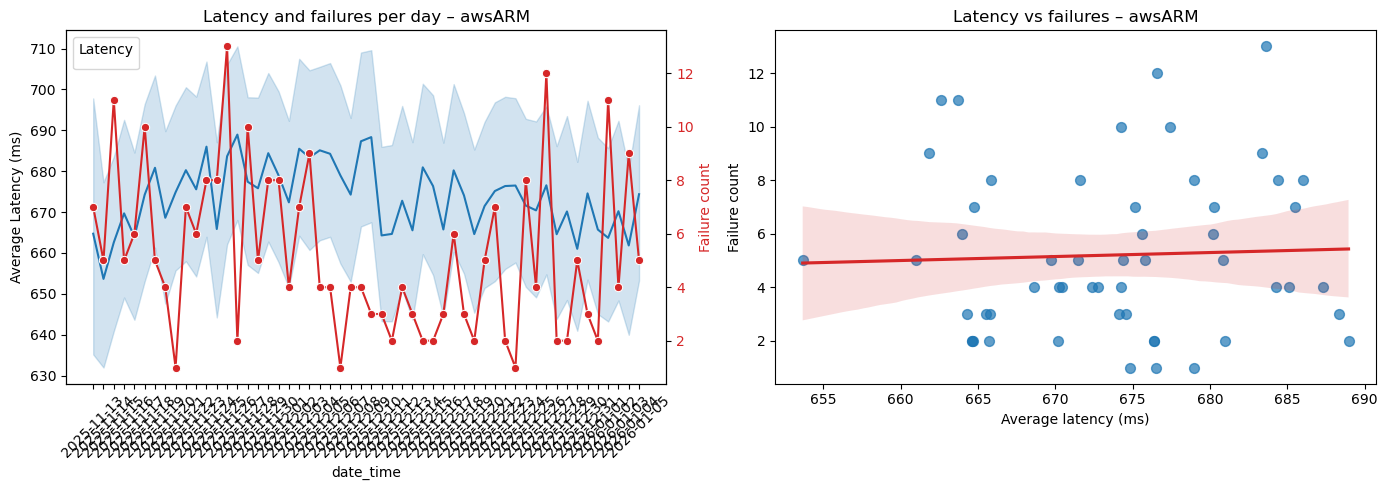

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


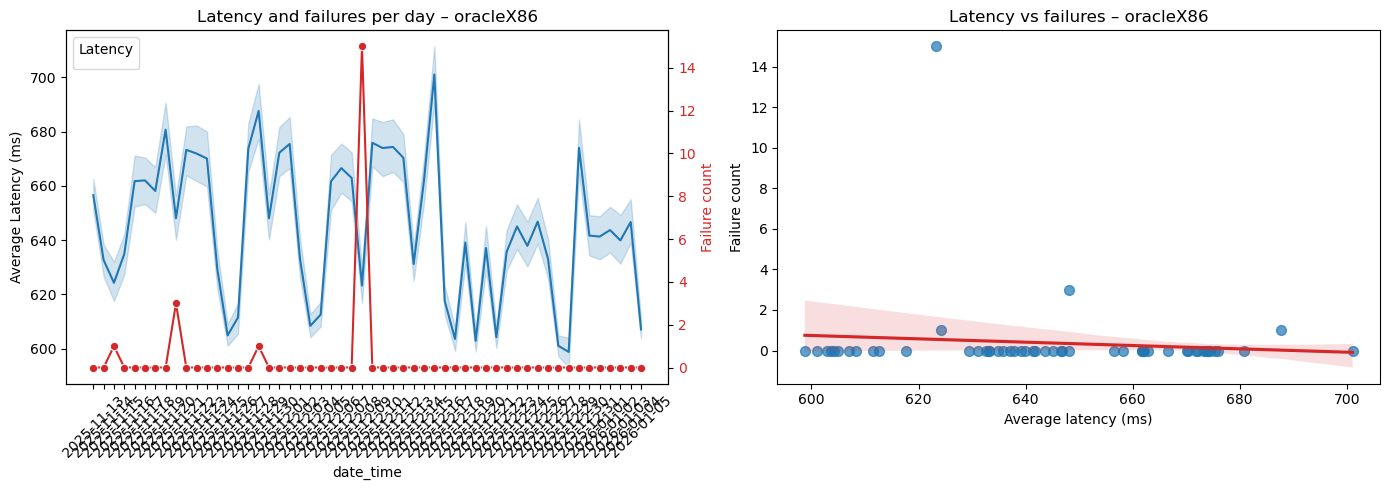

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


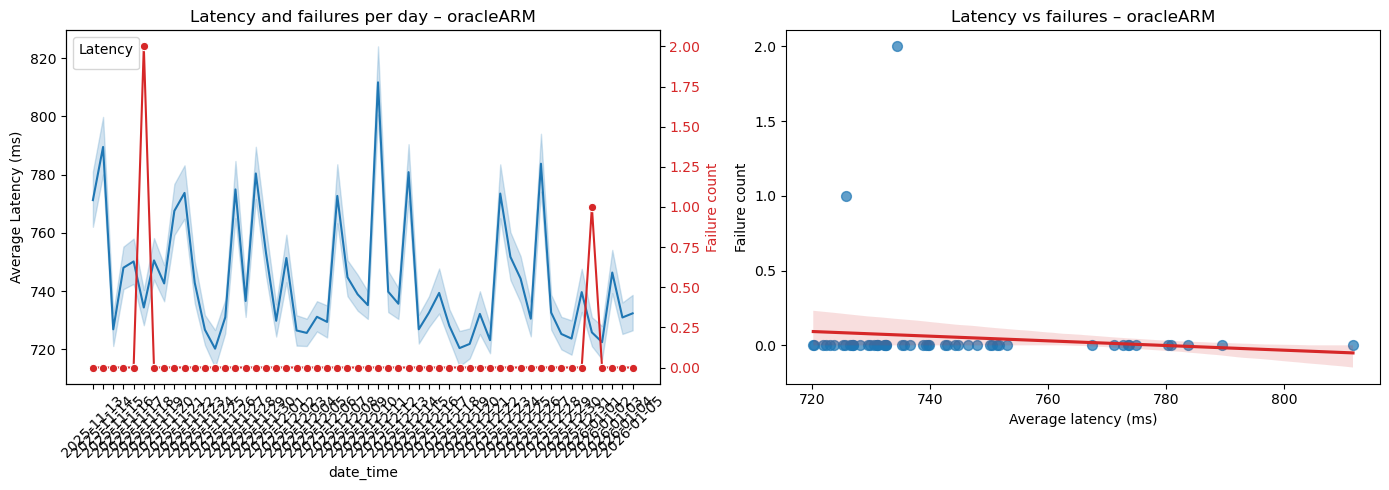

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


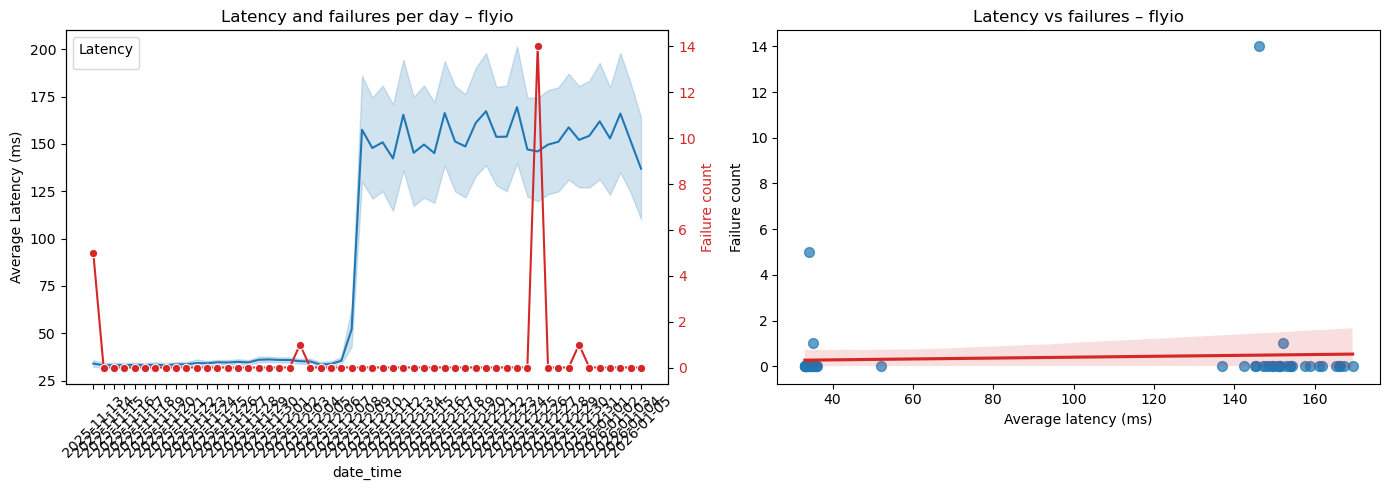

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


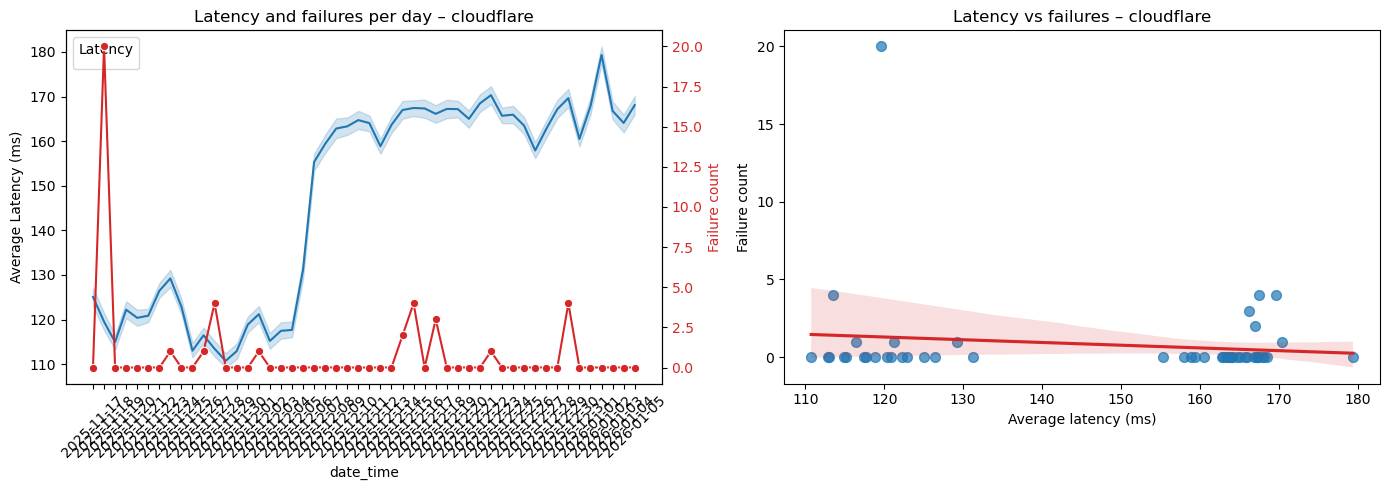

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


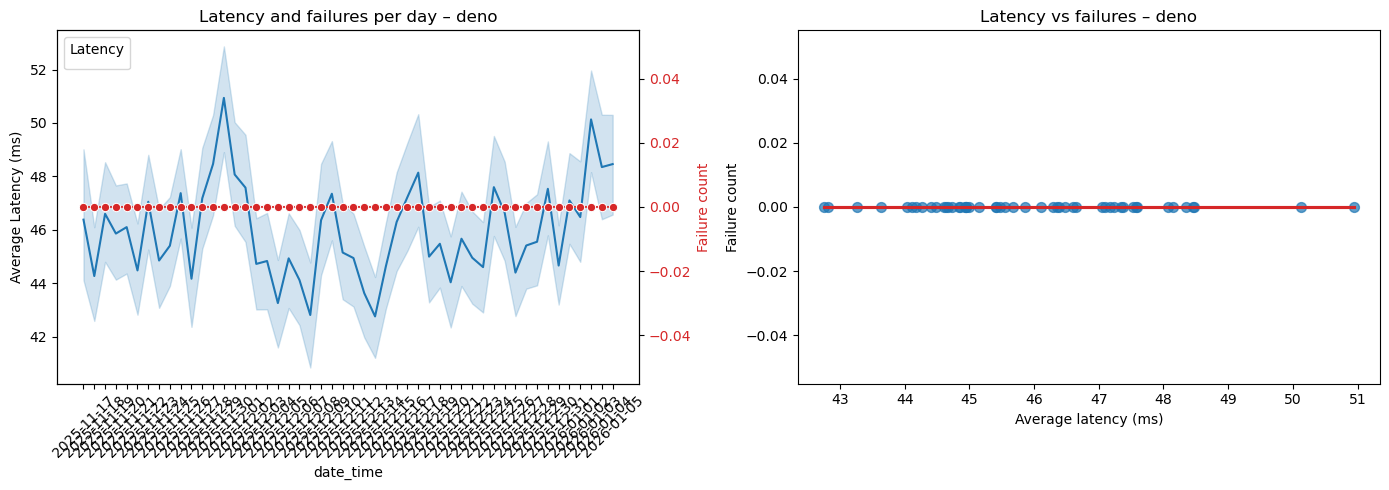

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65815/4130563145.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Latency", loc="upper left")


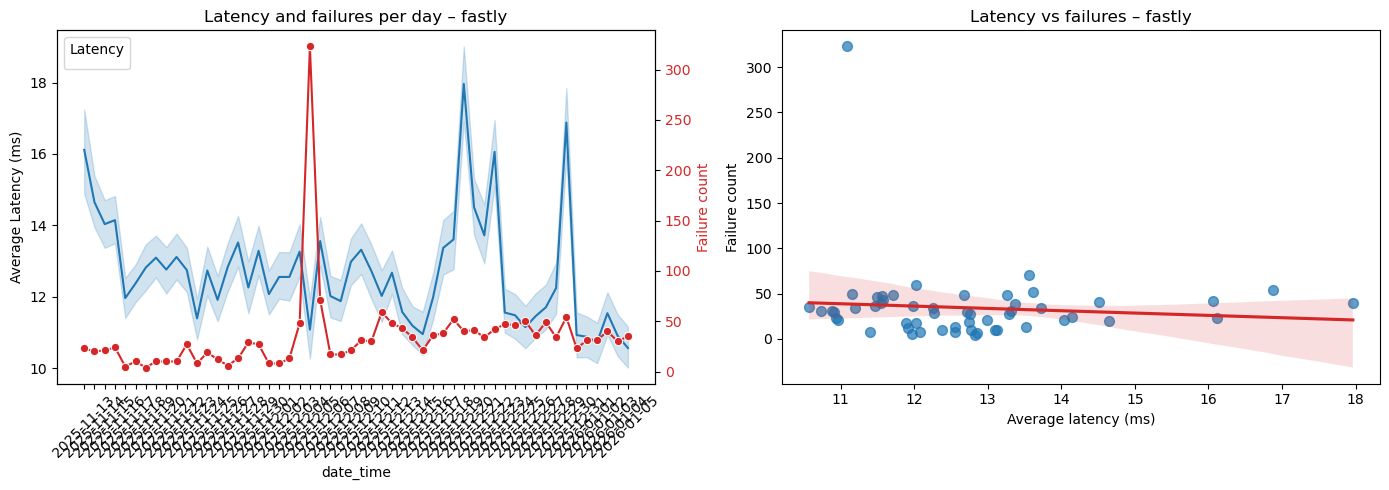

In [8]:
# Take a look at io performance over time

# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "cloudflare", "deno", "fastly"]  # <-- edit this list

df = pd.read_sql("select * from data where experiment = 'transfer'", cnx) 

for provider in providers:
    df_provider_raw = df[df["provider"] == provider].copy()
    if df_provider_raw.empty:
        continue
    df_provider_raw["date_time"] = df_provider_raw["date_time"].str[0:10]

    df_provider = df_provider_raw.copy()
    p99 = df_provider["transfer_latency"].quantile(0.99)
    df_provider = df_provider[df_provider["transfer_latency"] <= p99]
    
    # Aggregate daily latency and failures for scatterplot
    daily_latency = (
        df_provider.groupby("date_time", as_index=False)
        .agg(avg_latency=("transfer_latency", "mean"))
    )

    # Build a complete day index for this provider
    all_days = (
        df_provider_raw[["date_time"]]
        .drop_duplicates()
        .sort_values("date_time")
    )

    df_fail = (
        df_provider_raw[df_provider_raw["errorMessage"].notna()]
        .groupby("date_time", as_index=False)
        .size()
        .rename(columns={"size": "fail_count"})
    )

    # Ensure zero failures are shown for days with none
    df_fail = all_days.merge(df_fail, on="date_time", how="left").fillna({"fail_count": 0})

    daily = daily_latency.merge(df_fail, on="date_time", how="left").fillna({"fail_count": 0})

    fig, (ax, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Lineplot with twin y-axis
    sns.lineplot(
        data=df_provider,
        x="date_time",
        y="transfer_latency",
        ax=ax
    )

    ax2 = ax.twinx()
    sns.lineplot(
        data=df_fail,
        x="date_time",
        y="fail_count",
        ax=ax2,
        color="tab:red",
        marker="o"
    )

    ax.set_title(f"Latency and failures per day – {provider}")
    ax.set_ylabel("Average Latency (ms)")
    ax.legend(title="Latency", loc="upper left")
    ax2.set_ylabel("Failure count", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax.tick_params(axis="x", rotation=45)
    ax2.tick_params(axis="x", rotation=45)

    # Scatterplot: latency vs failures (with regression)
    sns.regplot(
        data=daily,
        x="avg_latency",
        y="fail_count",
        ax=ax_scatter,
        scatter_kws={"s": 50, "alpha": 0.7},
        line_kws={"color": "tab:red"}
    )
    ax_scatter.set_title(f"Latency vs failures – {provider}")
    ax_scatter.set_xlabel("Average latency (ms)")
    ax_scatter.set_ylabel("Failure count")

    plt.tight_layout()
    plt.show()

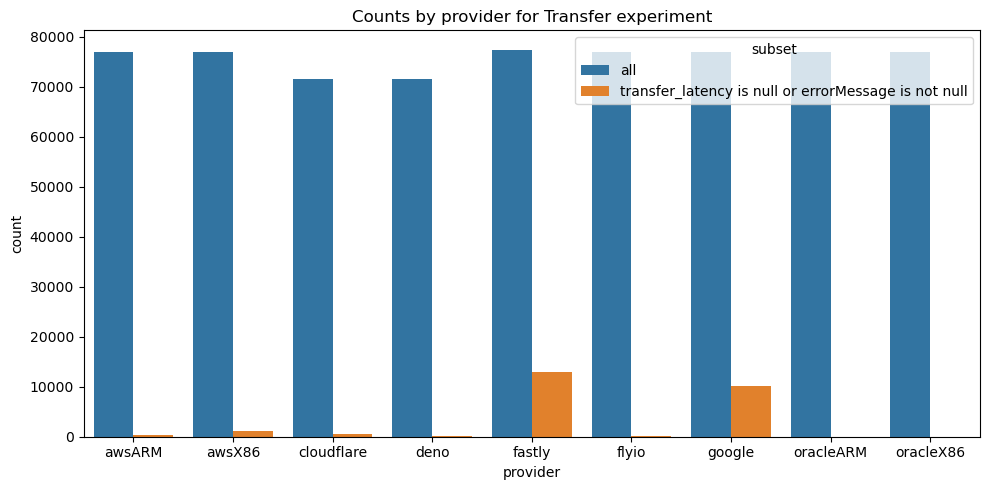

In [4]:
# Check if there is missing data and if there is a correlation

# Query counts for all rows
df_all = pd.read_sql_query("""
    SELECT
        provider,
        COUNT(*) AS count
    FROM data
    WHERE experiment = 'transfer'
    GROUP BY provider
""", cnx)

# Query counts where time_to_complete is NULL
df_null = pd.read_sql_query("""
    SELECT
        provider,
        COUNT(*) AS count
    FROM data
    WHERE experiment = 'transfer'
      AND (transfer_latency IS NULL OR errorMessage IS NOT NULL)
    GROUP BY provider
""", cnx)

# Add labels for hue
df_all["subset"] = "all"
df_null["subset"] = "transfer_latency is null or errorMessage is not null"

# Combine for plotting
df_plot = pd.concat([df_all, df_null], ignore_index=True)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_plot,
    x="provider",
    y="count",
    hue="subset"
)

plt.title("Counts by provider for Transfer experiment")
plt.tight_layout()
plt.show()

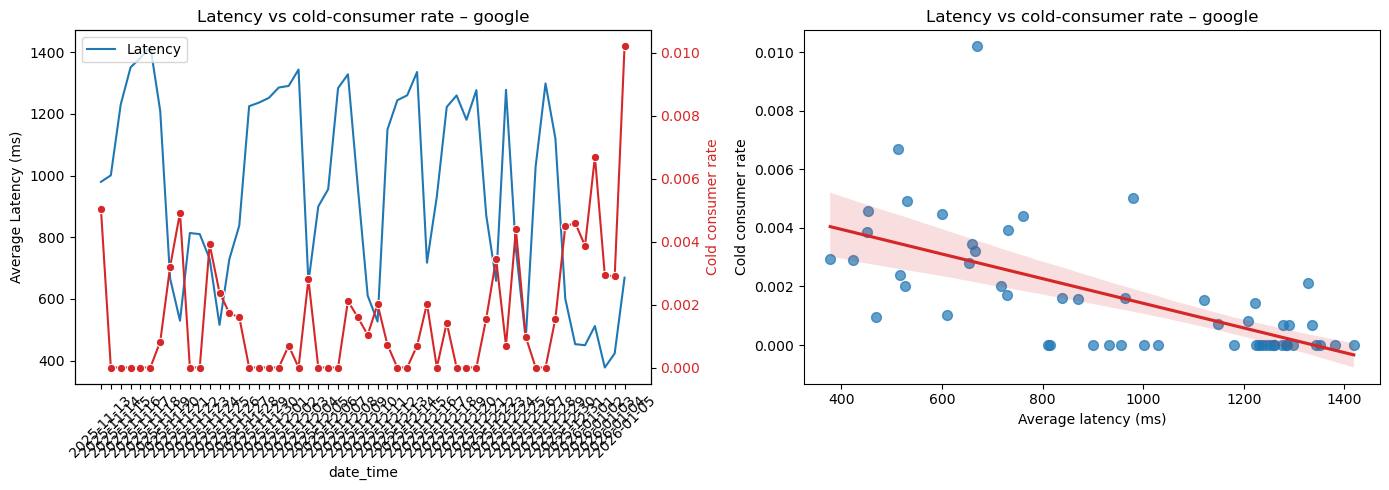

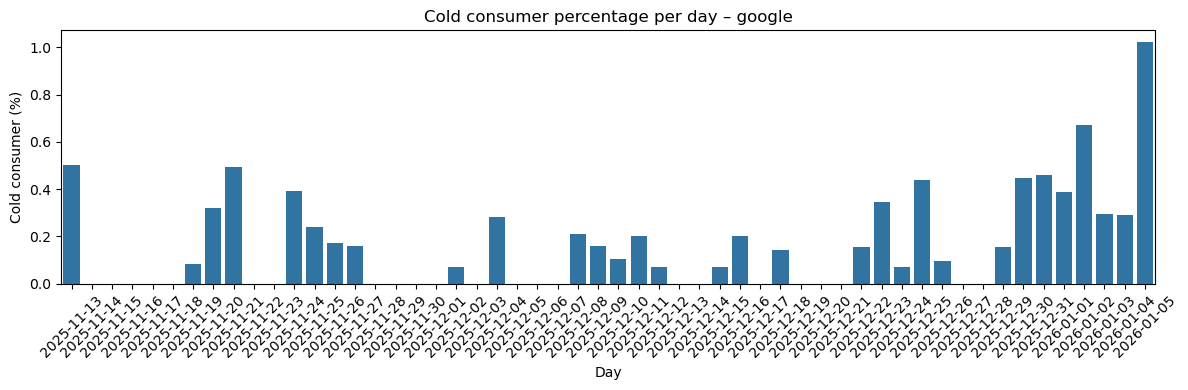

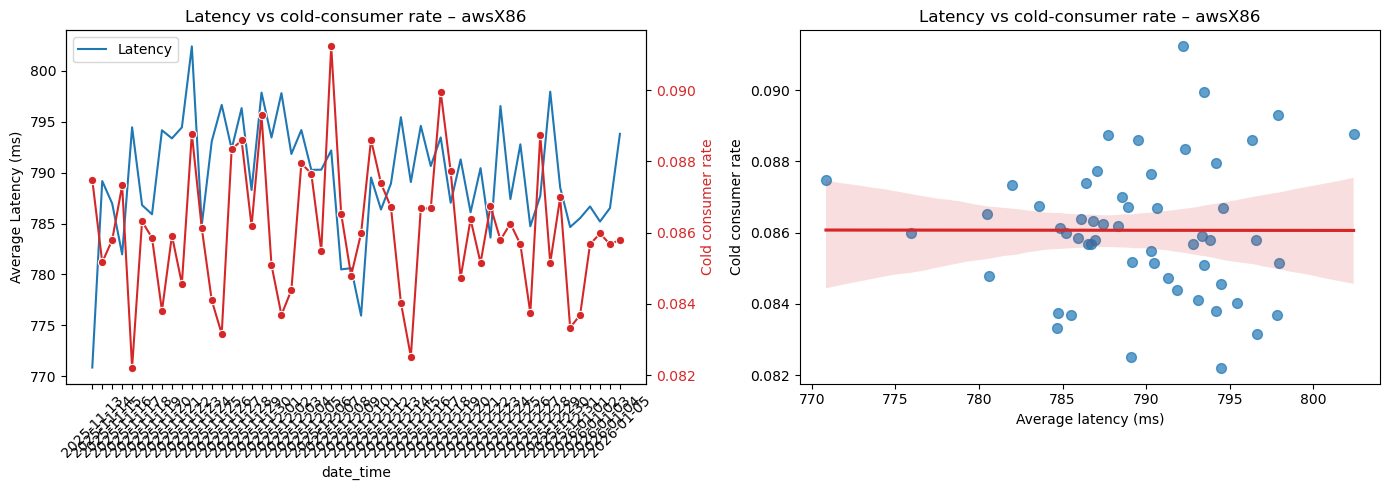

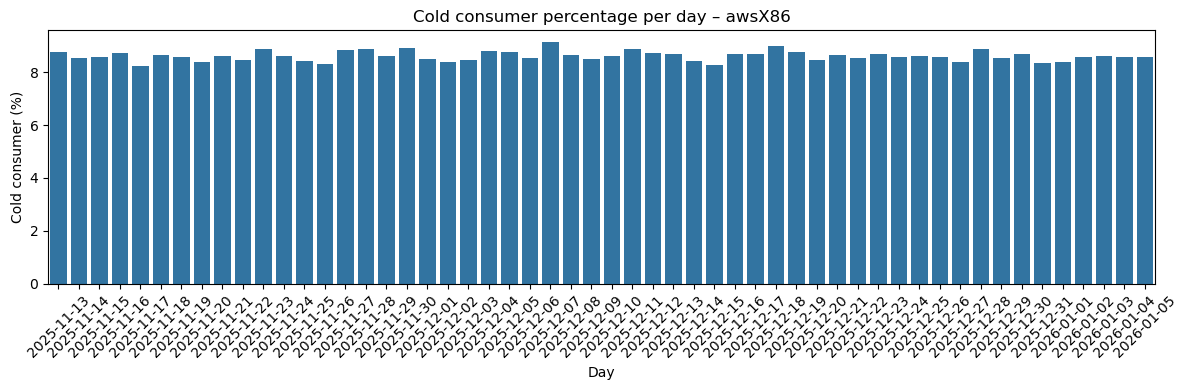

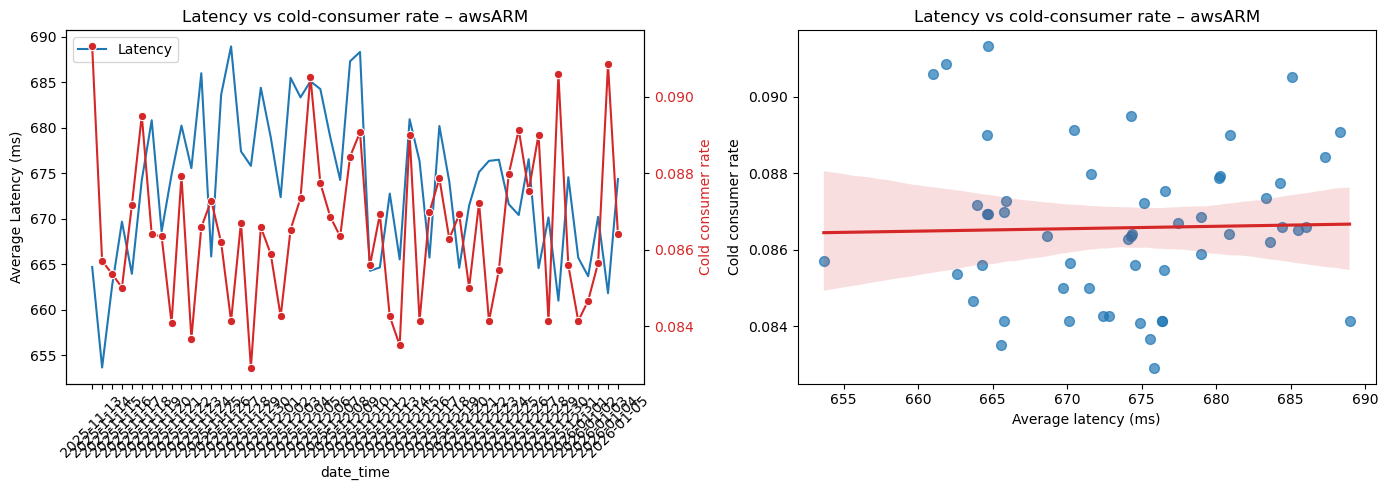

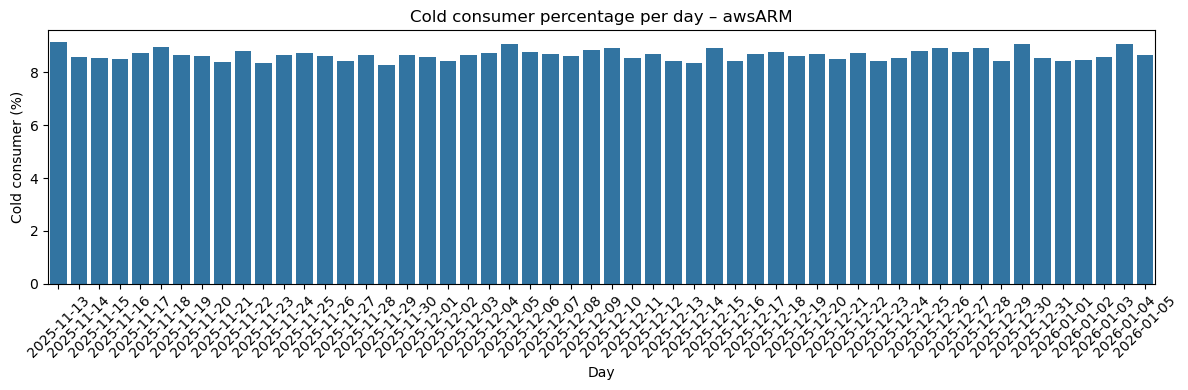

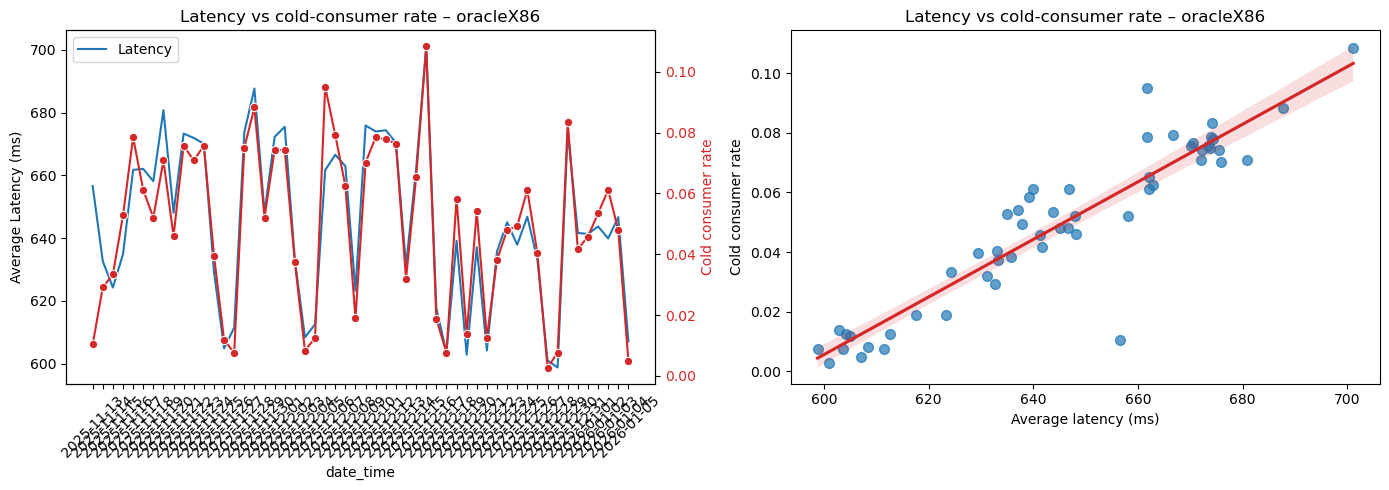

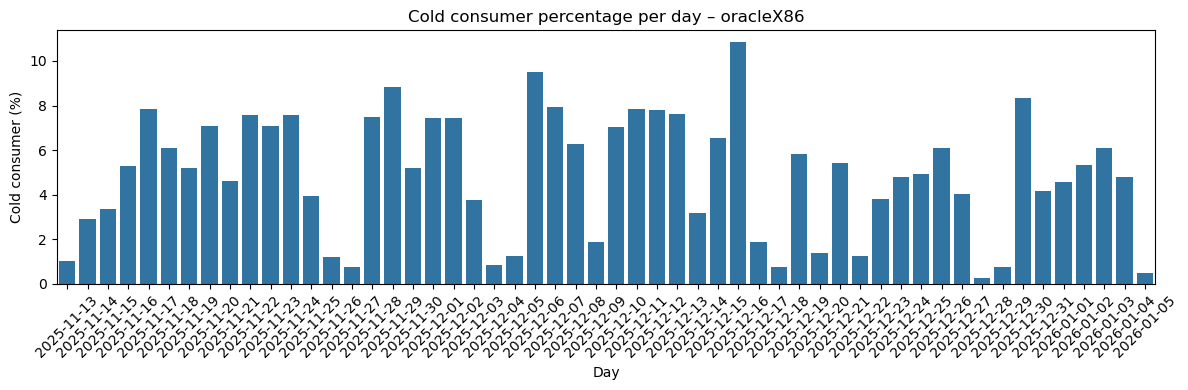

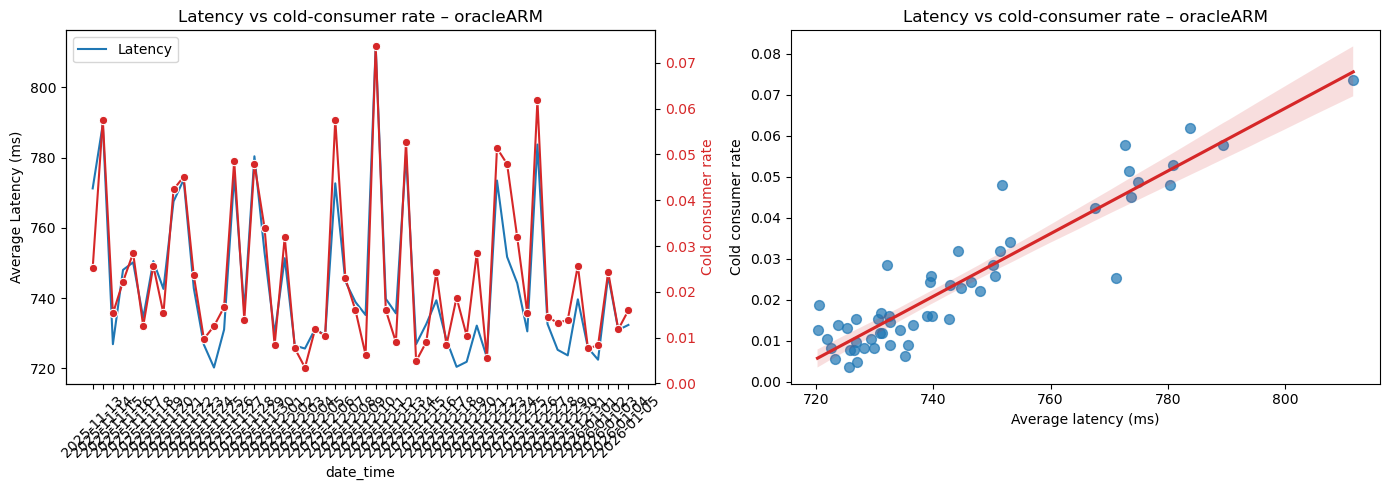

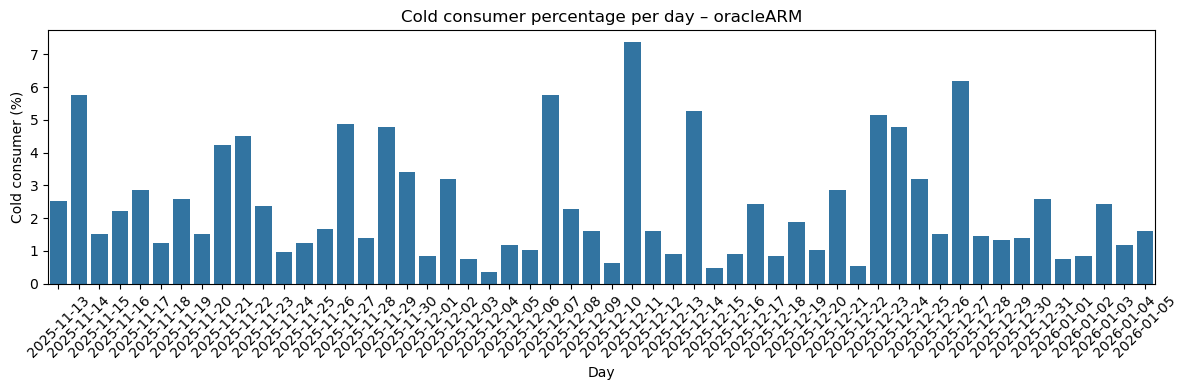

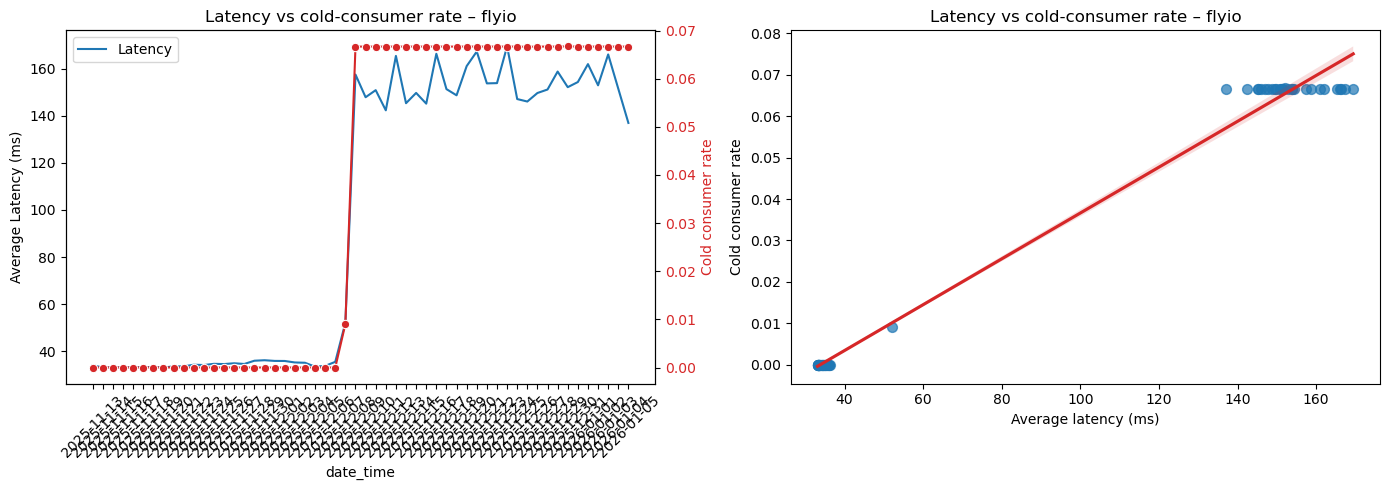

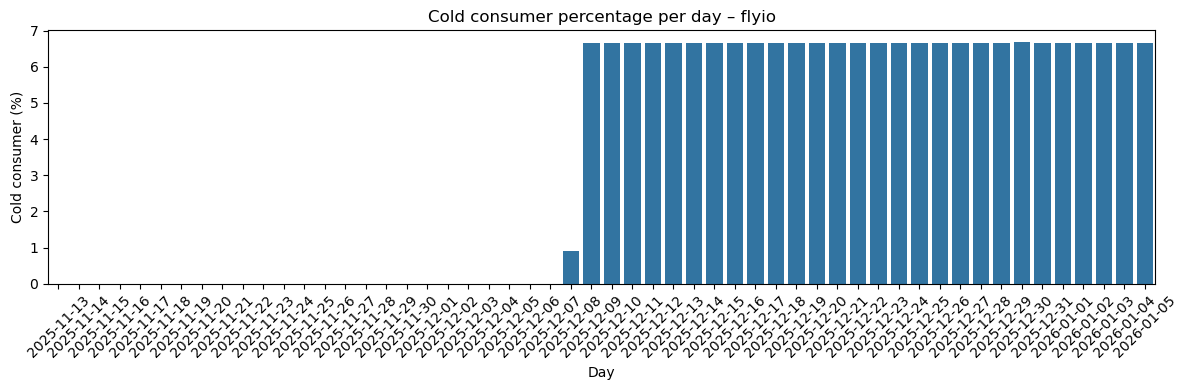

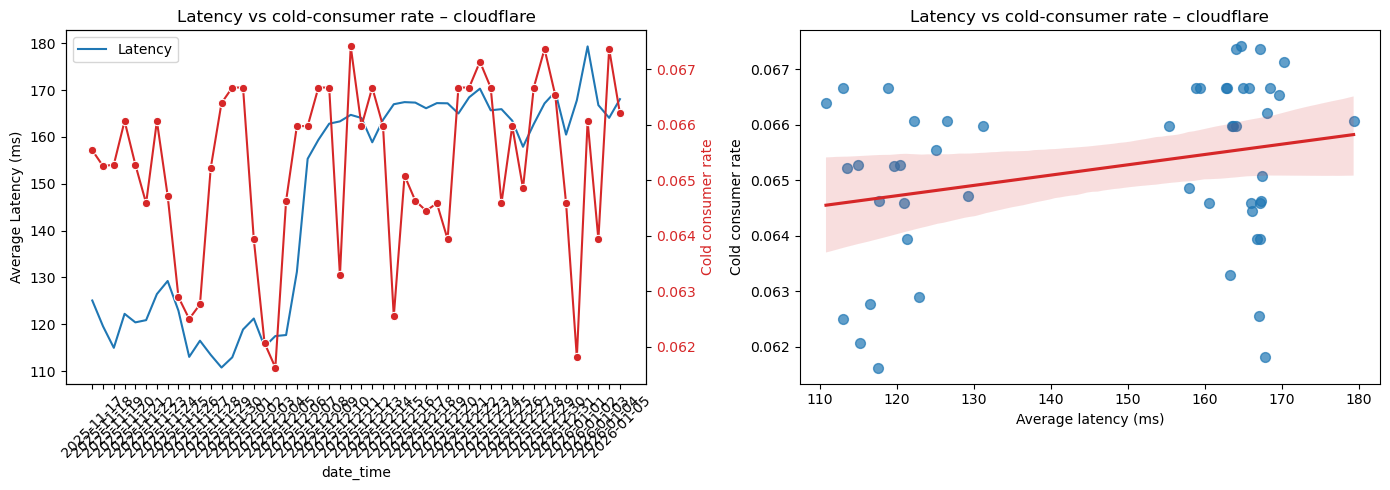

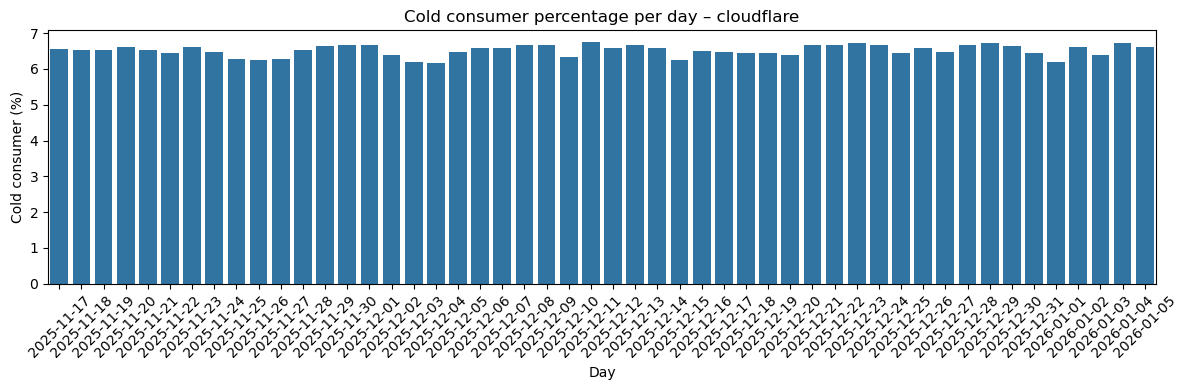

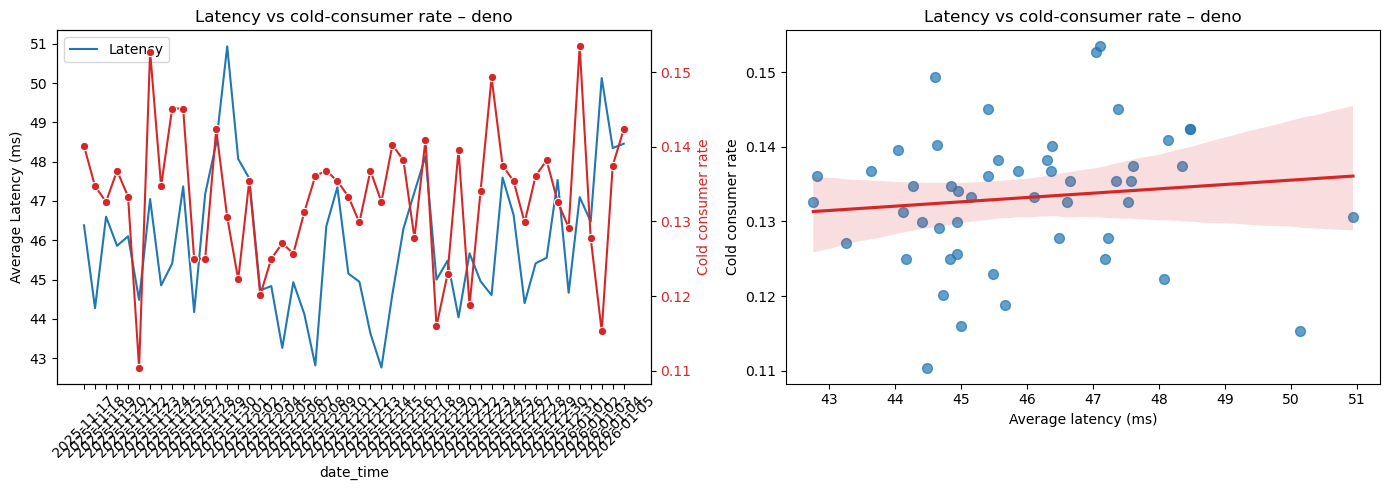

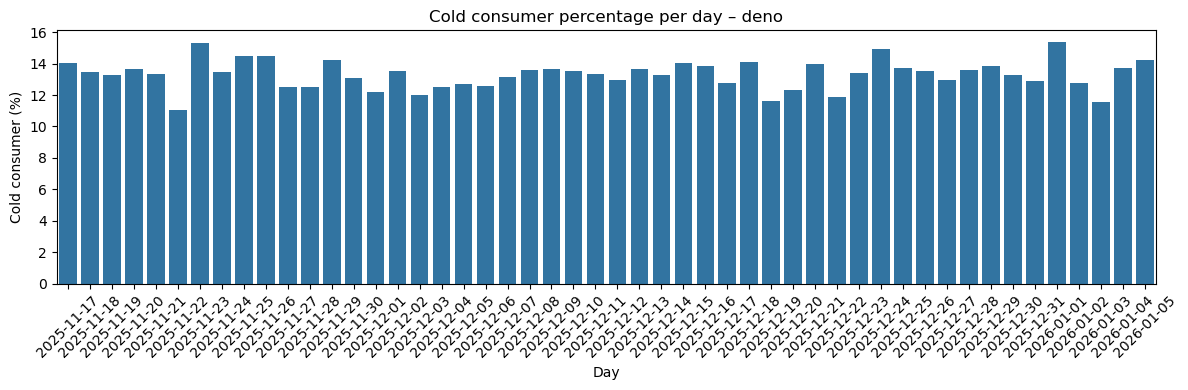

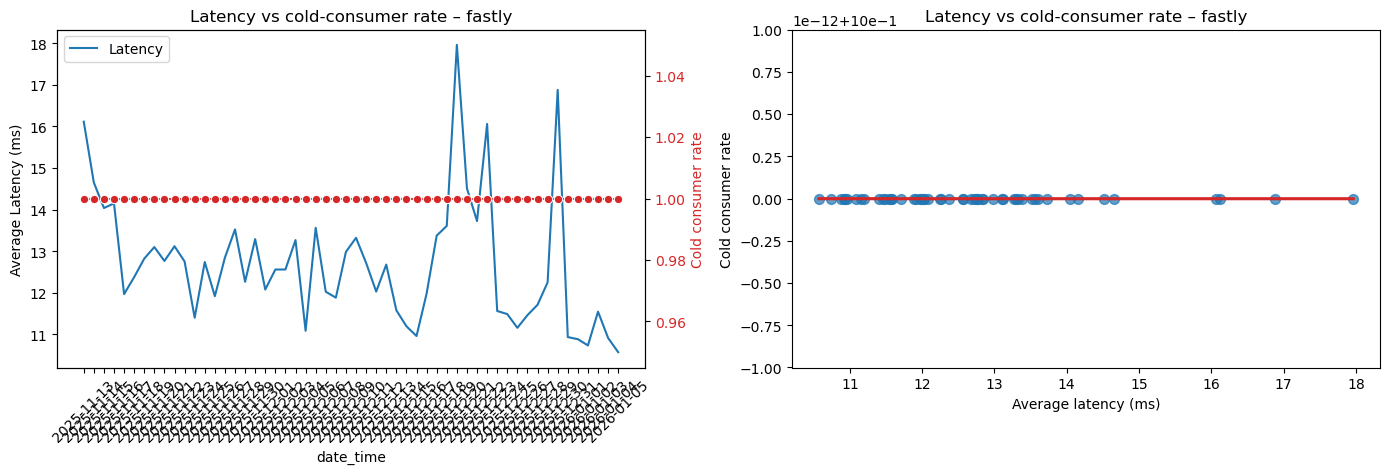

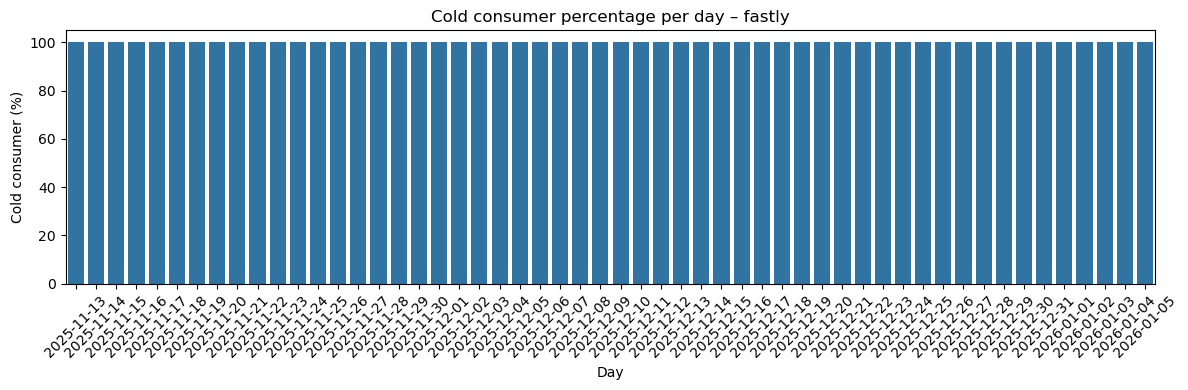

In [10]:
# Correlation between latency and consumer_cold (transfer experiment)

# Load transfer data with consumer_cold
df = pd.read_sql("select * from data where experiment = 'transfer'", cnx)

for provider in providers:
    df_provider_raw = df[df["provider"] == provider].copy()
    if df_provider_raw.empty:
        continue
    df_provider_raw["date_time"] = df_provider_raw["date_time"].str[0:10]

    # Ensure consumer_cold is numeric 0/1 and ignore missing
    df_provider_raw["consumer_cold"] = pd.to_numeric(df_provider_raw["consumer_cold"], errors="coerce")

    # Filter latency outliers similarly to above
    df_provider = df_provider_raw.copy()
    p99 = df_provider["transfer_latency"].quantile(0.99)
    df_provider = df_provider[df_provider["transfer_latency"] <= p99]

    # Daily aggregates: avg latency and cold rate
    daily_latency = (
        df_provider.groupby("date_time", as_index=False)
        .agg(avg_latency=("transfer_latency", "mean"))
    )

    daily_cold = (
        df_provider_raw.groupby("date_time", as_index=False)
        .agg(cold_rate=("consumer_cold", "mean"))
    )

    # Ensure full day index
    all_days = (
        df_provider_raw[["date_time"]]
        .drop_duplicates()
        .sort_values("date_time")
    )
    daily_cold = all_days.merge(daily_cold, on="date_time", how="left").fillna({"cold_rate": 0})
    daily = daily_latency.merge(daily_cold, on="date_time", how="left").fillna({"cold_rate": 0})

    fig, (ax, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Lineplot with twin y-axis: latency vs cold rate
    sns.lineplot(
        data=daily,
        x="date_time",
        y="avg_latency",
        ax=ax
    )
    ax2 = ax.twinx()
    sns.lineplot(
        data=daily,
        x="date_time",
        y="cold_rate",
        ax=ax2,
        color="tab:red",
        marker="o"
    )

    ax.set_title(f"Latency vs cold-consumer rate – {provider}")
    ax.set_ylabel("Average Latency (ms)")
    ax.legend(["Latency"], loc="upper left")
    ax2.set_ylabel("Cold consumer rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax.tick_params(axis="x", rotation=45)
    ax2.tick_params(axis="x", rotation=45)

    # Scatterplot: latency vs cold rate (with regression)
    sns.regplot(
        data=daily,
        x="avg_latency",
        y="cold_rate",
        ax=ax_scatter,
        scatter_kws={"s": 50, "alpha": 0.7},
        line_kws={"color": "tab:red"}
    )
    ax_scatter.set_title(f"Latency vs cold-consumer rate – {provider}")
    ax_scatter.set_xlabel("Average latency (ms)")
    ax_scatter.set_ylabel("Cold consumer rate")

    plt.tight_layout()
    plt.show()

    # Bar chart: % cold consumers per day
    daily_bar = daily_cold.copy()
    daily_bar["cold_rate_pct"] = daily_bar["cold_rate"] * 100.0

    plt.figure(figsize=(12, 4))
    sns.barplot(
        data=daily_bar,
        x="date_time",
        y="cold_rate_pct",
        color="tab:blue"
    )
    plt.title(f"Cold consumer percentage per day – {provider}")
    plt.xlabel("Day")
    plt.ylabel("Cold consumer (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()